In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
#load data set
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')


In [ ]:
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [ ]:
data.describe()

,Year,Rating
count,14981.000000,7919.000000
mean,-1987.012215,5.841621
std,25.416689,1.381777
min,-2022.000000,1.100000
25%,-2009.000000,4.900000
50%,-1991.000000,6.000000
75%,-1968.000000,6.800000
max,-1913.000000,10.000000


In [ ]:
#Check Missing Values
data.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [ ]:
#Remove Rows without Rating
data = data.dropna(subset=['Rating'])

In [ ]:
# Convert Year column to string first
data['Year'] = data['Year'].astype(str)

# Extract 4-digit year
data['Year'] = data['Year'].str.extract(r'(\d{4})', expand=False)

# Convert to numeric
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

In [ ]:
print(data['Year'].head(10))

1     2019
3     2019
5     1997
6     2005
8     2012
9     2014
10    2004
11    2016
12    1991
13    2012
Name: Year, dtype: int64


In [ ]:
data['Duration'] = data['Duration'].str.replace(' min','',regex=False)
data['Duration'] = pd.to_numeric(data['Duration'])

In [ ]:
data['Votes'] = data['Votes'].astype(str).str.replace(',', '')
data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')

In [ ]:
data = data.dropna(subset=['Rating'])

In [ ]:
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [ ]:
X = data.drop('Rating', axis=1)

y = data['Rating']

In [ ]:
categorical_features = [
    'Name',
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numerical_features = [
    'Year',
    'Duration',
    'Votes'
]

In [ ]:
numeric_transformer = SimpleImputer(strategy='median')

In [ ]:
categorical_transformer = Pipeline(
[
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(handle_unknown='ignore'))
]
)

In [ ]:
preprocessor = ColumnTransformer(
[
('num', numeric_transformer, numerical_features),
('cat', categorical_transformer, categorical_features)
]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [ ]:


model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=5,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])



In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Year', 'Duration',
                                                   'Votes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Name', 'Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=8, n_estimators=5, n_jobs=-1,
                                       random_state=42))])

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 0.8645728384856914


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

RMSE: 1.1305122743535754


In [ ]:
comparison = pd.DataFrame({
'Actual Rating': y_test,
'Predicted Rating': predictions
})

comparison.head(20)

,Actual Rating,Predicted Rating
9456,3.3,4.632053
14816,5.3,5.475684
3213,5.7,5.741102
3778,7.2,5.772936
5775,3.5,5.632457
12203,7.2,5.587190
12305,3.8,5.736390
4650,6.9,7.021587
8701,5.2,5.960264
4707,7.4,5.541205


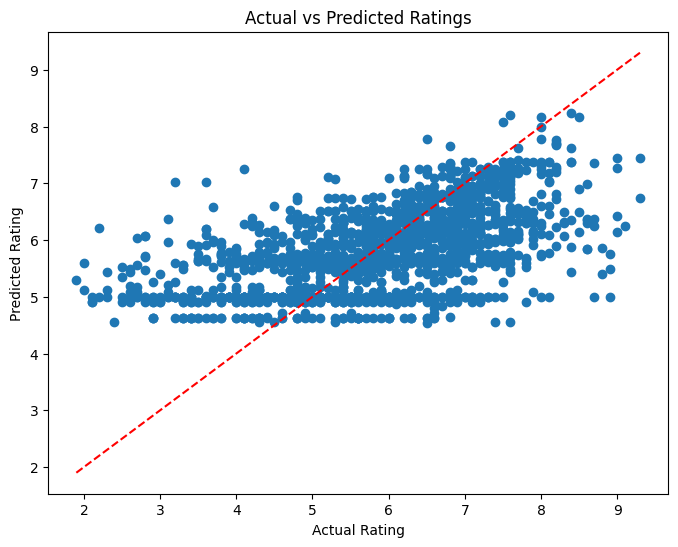

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

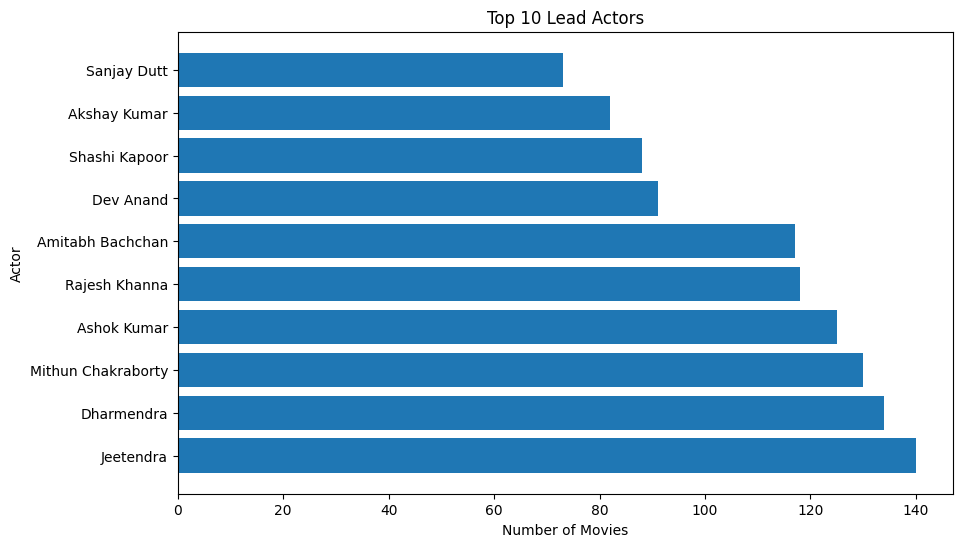

In [ ]:
actors = data['Actor 1'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(actors.index, actors.values)
plt.title("Top 10 Lead Actors")
plt.xlabel("Number of Movies")
plt.ylabel("Actor")
plt.show()